# Proyecto 1 - Etapa 2: Rentrenamiento de modelos
Integrantes


*   Anderson Arevalo Mendoza, 202014997
*   Juan José Hurtado Cantin, 202224472
*   Nicolas Perez Ramos, 202221292

Librerias

In [1]:
import pandas as pd
# Manejo de gráficas
!pip install scikit-plot
# librería Natural Language Toolkit, usada para trabajar con textos
import nltk
# Punkt permite separar un texto en frases.
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Instalación de librerias

import numpy as np

!pip install pandas-profiling
!pip install contractions
!pip install ydata-profiling
!pip install num2words

from num2words import num2words
from ydata_profiling import ProfileReport
import re, string, unicodedata
import contractions
import inflect
from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import LancasterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

import matplotlib.pyplot as plt
import copy

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.6/262.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.4/102.4 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.8/309.8 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.2 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=24a7f90c7dff284194ceaf3ad4a9c7f4622c5406aac26d5c3f9d5acdaf7e45cc
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.0
    Uninstalling multimethod-2.0:
      Successfully uninstalled multimethod-2.0
  Attempting uninstall: imagehash
    Found existing installation: ImageHash 4.3.2
    Uninstalling ImageHash-4.3.2:
      Successfully uninstalled ImageHash-4.3.2
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver 

Lectura de los datos



In [2]:
FilePath='./train.csv'
data=pd.read_csv(FilePath, sep=',')
X_data = data['Titulo'].astype(str) + " " + data['Descripcion'].astype(str)
y_data = data['Label']  # Etiqueta: 1 (Falso), 0 (Verdadero)

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

spanish_stopwords = stopwords.words('spanish')

vectorizer = TfidfVectorizer(max_features=5000, stop_words=spanish_stopwords)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#MODELO ORIGINAL



📈 Métricas de Evaluación Random Forest Classifier:
Exactitud (Accuracy): 0.9313
Precisión (Precision): 0.9180
Sensibilidad (Recall): 0.9735
F1-Score: 0.9449

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2114
           1       0.92      0.97      0.94      3243

    accuracy                           0.93      5357
   macro avg       0.94      0.92      0.93      5357
weighted avg       0.93      0.93      0.93      5357



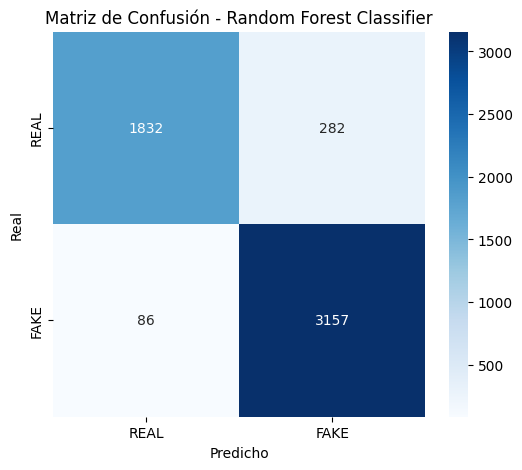

In [3]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=50, max_depth=2500, random_state=42)

clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("\n📈 Métricas de Evaluación Random Forest Classifier:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest Classifier')
plt.show()

# Datos de Reentrenamiento

In [4]:
RetrainPath = './retrainData.csv'
retrain_data = pd.read_csv(RetrainPath, sep=',')


X_Retrain = retrain_data['Titulo'].astype(str) + " " + retrain_data['Descripcion'].astype(str)
y_Retrain = retrain_data['Label']  # Etiqueta: 1 (Falso), 0 (Verdadero)

X1_train, X1_test, y1_train, y1_test = train_test_split(X_Retrain, y_Retrain, test_size=0.2, random_state=42)

spanish_stopwords = stopwords.words('spanish')

vectorizer = TfidfVectorizer(max_features=5000, stop_words=spanish_stopwords)
X1_train_tfidf = vectorizer.fit_transform(X1_train)
X1_test_tfidf = vectorizer.transform(X1_test)

# Rentrena modelo- propuesta Anderson Arevalo: Reentrenamiento Completo (Batch Learning)


📈 Métricas de Evaluación Random Forest Classifier:
Exactitud (Accuracy): 0.9139
Precisión (Precision): 0.8987
Sensibilidad (Recall): 0.9649
F1-Score: 0.9306

📋 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       574
           1       0.90      0.96      0.93       855

    accuracy                           0.91      1429
   macro avg       0.92      0.90      0.91      1429
weighted avg       0.92      0.91      0.91      1429



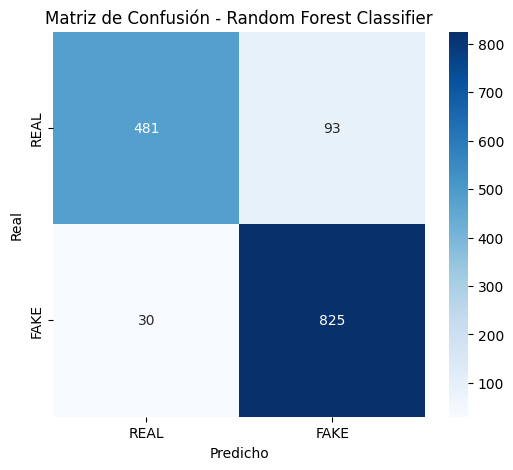

In [5]:
clfAAM = copy.deepcopy(clf)
clfAAM.fit(X1_train_tfidf, y1_train)

y1_pred = clfAAM.predict(X1_test_tfidf)
accuracy = accuracy_score(y1_test, y1_pred)
precision = precision_score(y1_test, y1_pred, pos_label=1)
recall = recall_score(y1_test, y1_pred, pos_label=1)
f1 = f1_score(y1_test, y1_pred, pos_label=1)

print("\n📈 Métricas de Evaluación Random Forest Classifier:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n📋 Reporte de Clasificación:")
print(classification_report(y1_test, y1_pred))

conf_matrix = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest Classifier')
plt.show()

# Rentrena modelo- propuesta


📈 Métricas de Evaluación - Reentrenamiento Incremental:
Exactitud (Accuracy): 0.9356
Precisión (Precision): 0.9080
Sensibilidad (Recall): 0.9930
F1-Score: 0.9486

📋 Reporte de Clasificación - Reentrenamiento Incremental:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       574
           1       0.91      0.99      0.95       855

    accuracy                           0.94      1429
   macro avg       0.95      0.92      0.93      1429
weighted avg       0.94      0.94      0.93      1429



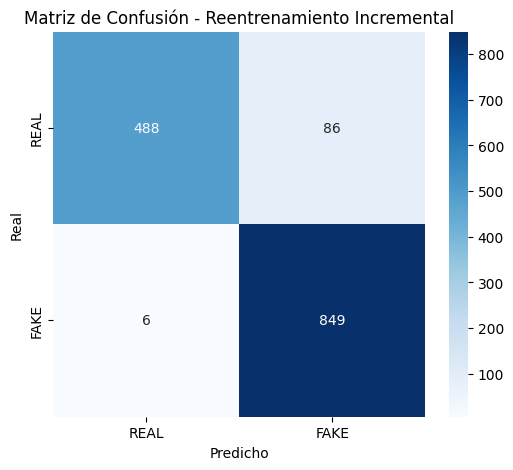

In [11]:
clf_incremental = SGDClassifier(loss="log_loss", random_state=42)

X_retrain_tfidf = vectorizer.transform(X_Retrain)

clf_incremental.partial_fit(X_retrain_tfidf, y_Retrain, classes=np.array([0, 1]))

y_retrain_pred = clf_incremental.predict(X1_test_tfidf)
accuracy = accuracy_score(y1_test, y_retrain_pred)
precision = precision_score(y1_test, y_retrain_pred, pos_label=1)
recall = recall_score(y1_test, y_retrain_pred, pos_label=1)
f1 = f1_score(y1_test, y_retrain_pred, pos_label=1)

print("\n📈 Métricas de Evaluación - Reentrenamiento Incremental:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n📋 Reporte de Clasificación - Reentrenamiento Incremental:")
print(classification_report(y1_test, y_retrain_pred))

conf_matrix = confusion_matrix(y1_test, y_retrain_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Reentrenamiento Incremental')
plt.show()

# Rentrena modelo- propuesta


📈 Métricas de Evaluación - Reentrenamiento con Ventanas Deslizantes:
Exactitud (Accuracy): 0.8880
Precisión (Precision): 0.8594
Sensibilidad (Recall): 0.9719
F1-Score: 0.9122

📋 Reporte de Clasificación - Reentrenamiento con Ventanas Deslizantes:
              precision    recall  f1-score   support

           0       0.95      0.76      0.85       574
           1       0.86      0.97      0.91       855

    accuracy                           0.89      1429
   macro avg       0.90      0.87      0.88      1429
weighted avg       0.89      0.89      0.89      1429



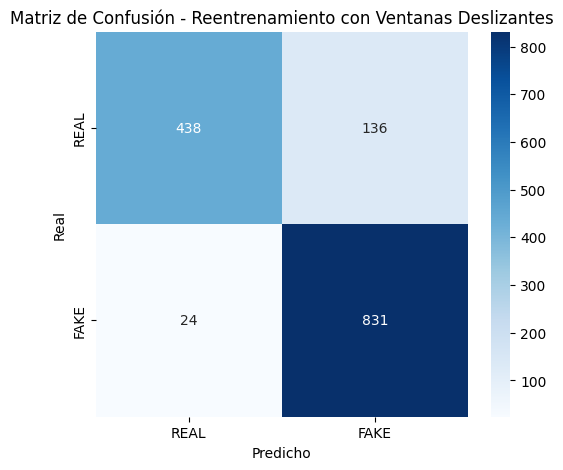

In [12]:
window_size = 1000

clf_window = copy.deepcopy(clf)

X_window_tfidf = vectorizer.transform(X_Retrain[-window_size:])
y_window = y_Retrain[-window_size:]

clf_window.fit(X_window_tfidf, y_window)

y_window_pred = clf_window.predict(X1_test_tfidf)
accuracy = accuracy_score(y1_test, y_window_pred)
precision = precision_score(y1_test, y_window_pred, pos_label=1)
recall = recall_score(y1_test, y_window_pred, pos_label=1)
f1 = f1_score(y1_test, y_window_pred, pos_label=1)

print("\n📈 Métricas de Evaluación - Reentrenamiento con Ventanas Deslizantes:")
print(f"Exactitud (Accuracy): {accuracy:.4f}")
print(f"Precisión (Precision): {precision:.4f}")
print(f"Sensibilidad (Recall): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n📋 Reporte de Clasificación - Reentrenamiento con Ventanas Deslizantes:")
print(classification_report(y1_test, y_window_pred))

conf_matrix = confusion_matrix(y1_test, y_window_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Reentrenamiento con Ventanas Deslizantes')
plt.show()

# Descargar Modelo Original 

In [ ]:
import joblib


joblib.dump(clf, "modelo.joblib")